This colab runs BERT on our data 

In [ ]:
!pip install opendatasets -q

import opendatasets as od
od.download('https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres?select=songs.csv')
od.download('https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nhern026
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres


100%|██████████| 235M/235M [00:02<00:00, 116MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nhern026
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs


100%|██████████| 3.05M/3.05M [00:00<00:00, 239MB/s]

In [ ]:
import pandas as pd
import re

#loading datasets from kaggle
songs_df   = pd.read_csv('/content/550k-spotify-songs-audio-lyrics-and-genres/songs.csv')
charts_df  = pd.read_csv('/content/billboard-the-hot-100-songs/charts.csv')

print('songs_df columns:', songs_df.columns.tolist())
print('songs_df shape:  ', songs_df.shape)

songs_df columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
songs_df shape:   (550622, 24)


In [ ]:
songs_df['decade'] = (songs_df['year'] // 10 * 10).astype(str) + 's'
print(songs_df.groupby('decade').size().to_string())

decade
1900s        30
1910s         3
1920s       156
1930s       288
1940s       437
1950s      4119
1960s     11344
1970s     17570
1980s     20729
1990s     42913
2000s    162161
2010s    225362
2020s     65510


In [ ]:
import ast

def normalize_text(text):
    if pd.isna(text): return ''
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

#removing the featuere title in artist lists
def clean_artist_name(artist):
    for sep in [' featuring ', ' feat. ', ' feat ', ' ft. ', ' ft ', ' x ', ' & ', ' with ']:
        artist = artist.lower().split(sep)[0]
    return artist.strip()

# some songs have multiple artists listed as a stringified list, we need to extract the primary artist for matching
def get_primary_artist(artists_str):
    try:
        artists_list = ast.literal_eval(artists_str)
        return normalize_text(artists_list[0])
    except:
        return clean_artist_name(normalize_text(str(artists_str)))

# normalizing our datasets
songs_df['song_normalized']   = songs_df['name'].apply(normalize_text)
songs_df['artist_normalized'] = songs_df['artists'].apply(get_primary_artist)

charts_df['song_normalized']   = charts_df['song'].apply(normalize_text)
charts_df['artist_normalized'] = charts_df['artist'].apply(lambda x: clean_artist_name(normalize_text(x)))

In [ ]:
# creating the is_hit label feature to songs dataframe
# a song is a hit if it ever reached top 10, matched on song + artist name
top10 = charts_df[charts_df['rank'] <= 10][['song_normalized', 'artist_normalized']].drop_duplicates()
top10['is_hit'] = 1

songs_df = songs_df.merge(top10, on=['song_normalized', 'artist_normalized'], how='left')
songs_df['is_hit'] = songs_df['is_hit'].fillna(0).astype(int)

print(f"Total songs:  {len(songs_df):,}")
print(f"Hits (top10): {songs_df['is_hit'].sum():,}")
print(f"Overall hit rate: {songs_df['is_hit'].mean():.1%}")

Total songs:  550,622
Hits (top10): 7,292
Overall hit rate: 1.3%


In [ ]:
# checking how many hits we have per decade in a percentage (not a lot!)
decade_stats = songs_df.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

         total  hits hit_rate
decade                       
1960s    11344   437     3.9%
1970s    17570   604     3.4%
1980s    20729   796     3.8%
1990s    42913   850     2.0%
2000s   162161  1821     1.1%
2010s   225362  2128     0.9%
2020s    65510   620     0.9%


In [ ]:
# this dataset only uses non-hits that are popularity 0 metric

print(songs_df.columns.tolist())
songs_df_unPop = songs_df[~((songs_df['popularity'] > 0) & (songs_df['is_hit'] == 0))]

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
# checking how many hits we have per decade in a percentage after taking out non-zero non_hit songs
decade_stats = songs_df_unPop.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

        total  hits hit_rate
decade                      
1960s    1798   437    24.3%
1970s    3496   604    17.3%
1980s    4212   796    18.9%
1990s   10536   850     8.1%
2000s   43777  1821     4.2%
2010s   70817  2128     3.0%
2020s   18636   620     3.3%


In [ ]:
# @title Downsample 1700 - downsample only with 0 popularity songs for non-hits
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df_unPop.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 340
    target_non_hits = 340 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_1700_unPOP_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_1700_unPOP_df):,} songs")

1960s: 340 hits, 1360 non-hits, hit rate: 20.0%
1970s: 340 hits, 1360 non-hits, hit rate: 20.0%
1980s: 340 hits, 1360 non-hits, hit rate: 20.0%
1990s: 340 hits, 1360 non-hits, hit rate: 20.0%
2000s: 340 hits, 1360 non-hits, hit rate: 20.0%
2010s: 340 hits, 1360 non-hits, hit rate: 20.0%
2020s: 340 hits, 1360 non-hits, hit rate: 20.0%

Total: 11,900 songs


In [ ]:
# @title Downsample 2000 - random Downsample
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 400
    target_non_hits = 400 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_2000_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_2000_df):,} songs")

1960s: 400 hits, 1600 non-hits, hit rate: 20.0%
1970s: 400 hits, 1600 non-hits, hit rate: 20.0%
1980s: 400 hits, 1600 non-hits, hit rate: 20.0%
1990s: 400 hits, 1600 non-hits, hit rate: 20.0%
2000s: 400 hits, 1600 non-hits, hit rate: 20.0%
2010s: 400 hits, 1600 non-hits, hit rate: 20.0%
2020s: 400 hits, 1600 non-hits, hit rate: 20.0%

Total: 14,000 songs


In [ ]:
# @title Downsample Full
# downsampling to 20% hit rate
balanced_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_non_hits = min(len(hits) * 4, len(non_hits))
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced = pd.concat([hits, non_hits_sampled])
    balanced_decades.append(balanced)
    print(f"{decade}: {len(hits)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits)/len(balanced):.1%}")

balanced_df = pd.concat(balanced_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_df):,} songs")

1960s: 437 hits, 1748 non-hits, hit rate: 20.0%
1970s: 604 hits, 2416 non-hits, hit rate: 20.0%
1980s: 796 hits, 3184 non-hits, hit rate: 20.0%
1990s: 850 hits, 3400 non-hits, hit rate: 20.0%
2000s: 1821 hits, 7284 non-hits, hit rate: 20.0%
2010s: 2128 hits, 8512 non-hits, hit rate: 20.0%
2020s: 620 hits, 2480 non-hits, hit rate: 20.0%

Total: 36,280 songs


In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
#removing the unecessary columns from our datasets.

balanced_2000_df = balanced_2000_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]
balanced_df = balanced_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]
balanced_1700_unPOP_df = balanced_1700_unPOP_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]

In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']


BELOW IS THE CODE TO LOAD, TRAIN, and EVALUATE

In [ ]:
!pip install transformers datasets evaluate -q


import os
os.environ["WANDB_DISABLED"] = "true"

import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from evaluate import load

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
# @title BERT!

# loading in model/tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# converting dataset to work for BERT
df = balanced_2000_df[["lyrics", "is_hit"]].dropna(subset=["lyrics"]).copy()
df = df.rename(columns={"lyrics": "text", "is_hit": "label"})

dataset = Dataset.from_pandas(df, preserve_index=False)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

# tokenizing the dataset
tokenized_train = dataset["train"].map(preprocess_function)
tokenized_test  = dataset["test"].map(preprocess_function)

def compute_metrics(eval_pred):
    load_accuracy = load("accuracy")
    load_f1 = load("f1")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": accuracy, "f1": f1}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

In [ ]:
results = {}

for decade, group in balanced_2000_df.groupby("decade"):
    print(f"\n {decade}")

    df = group[["lyrics", "is_hit"]].dropna(subset=["lyrics"]).copy()
    df = df.rename(columns={"lyrics": "text", "is_hit": "label"})

    dataset = Dataset.from_pandas(df, preserve_index=False)
    dataset = dataset.train_test_split(test_size=0.2, seed=42)

    tokenized_train = dataset["train"].map(preprocess_function)
    tokenized_test  = dataset["test"].map(preprocess_function)

    model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    results[decade] = metrics
    print(f"{decade} → {metrics}")

print("\nAll Decade Results")
for decade, m in results.items():
    print(f"{decade}: accuracy={m['eval_accuracy']:.3f}, f1={m['eval_f1']:.3f}")


========== 1960s ==========


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.238317


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2020s → {'eval_loss': 0.36962375044822693, 'eval_accuracy': 0.89, 'eval_f1': 0.6986301369863014, 'eval_runtime': 7.3098, 'eval_samples_per_second': 54.721, 'eval_steps_per_second': 3.42, 'epoch': 5.0}

===== All Decade Results =====
1960s: accuracy=0.790, f1=0.462
1970s: accuracy=0.790, f1=0.432
1980s: accuracy=0.782, f1=0.479
1990s: accuracy=0.818, f1=0.583
2000s: accuracy=0.830, f1=0.507
2010s: accuracy=0.828, f1=0.610
2020s: accuracy=0.890, f1=0.699


In [ ]:
print("\n===== All Decade Results =====")
for decade, m in results.items():
    print(f"{decade}: accuracy={m['eval_accuracy']:.3f}, f1={m['eval_f1']:.3f}")


===== All Decade Results =====
1960s: accuracy=0.790, f1=0.462
1970s: accuracy=0.790, f1=0.432
1980s: accuracy=0.782, f1=0.479
1990s: accuracy=0.818, f1=0.583
2000s: accuracy=0.830, f1=0.507
2010s: accuracy=0.828, f1=0.610
2020s: accuracy=0.890, f1=0.699


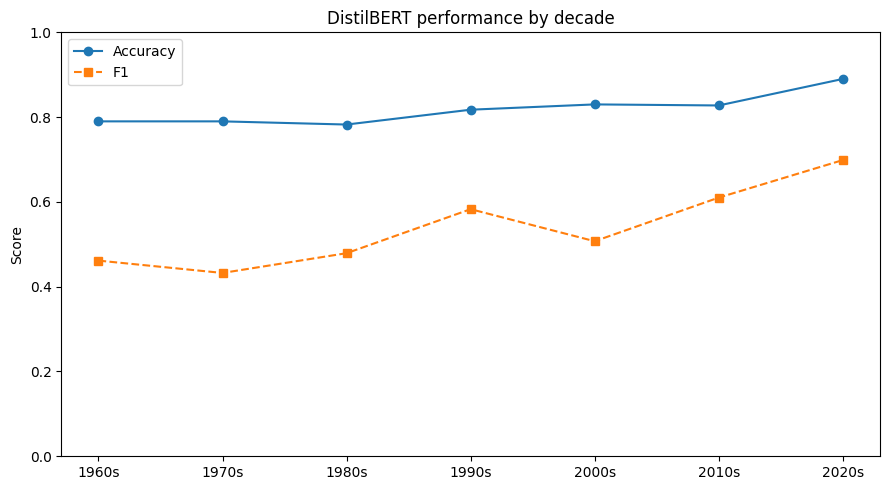

In [ ]:
import matplotlib.pyplot as plt

decades  = list(results.keys())
accuracy = [results[d]['eval_accuracy'] for d in decades]
f1       = [results[d]['eval_f1'] for d in decades]

plt.figure(figsize=(9, 5))
plt.plot(decades, accuracy, marker='o', label='Accuracy')
plt.plot(decades, f1,       marker='s', linestyle='--', label='F1')
plt.ylim(0.0, 1.0)
plt.ylabel('Score')
plt.title('DistilBERT performance by decade')
plt.legend()
plt.tight_layout()
plt.show()